<a href="https://colab.research.google.com/github/atikhasan007/DeepLearning/blob/main/pytorch/13_Feed-Forward%20Neural%20Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MNIST
# DataLoader , Transformation
# Multilayer Neural Net , activation function
# Loss and Optimizer
# Training Loop (batch training)
# Module evaluation
# GPU support


step 01: library import

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
# hyper parameters
input_size = 784 # 28 * 28
hidden_size = 100
num_classes = 10
num_epochs = 2
batch_size = 100
learning_rate = 0.001

In [7]:
# MNIST
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.34MB/s]


In [8]:
# dataloader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [10]:
examples = iter(train_loader)
samples , labels = next(examples)
print(samples.shape, labels.shape)

torch.Size([100, 1, 28, 28]) torch.Size([100])


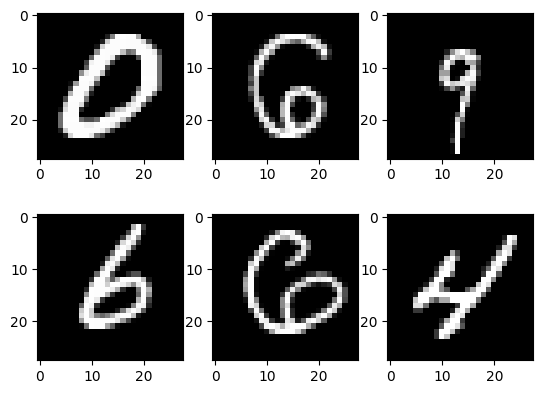

In [11]:
for i in range(6):
  plt.subplot(2,3, i+1)
  plt.imshow(samples[i][0], cmap='gray')
plt.show()

In [12]:
class NeuralNet(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(NeuralNet, self).__init__()
    self.l1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    return out

In [13]:
model = NeuralNet(input_size, hidden_size, num_classes)



In [14]:
#loss and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [16]:
# training loop
model.to(device)
n_total_steps = len(train_loader)
for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    # 100 1 28 28
    # 100, 784

    images = images.reshape(-1, 28*28).to(device)
    labels = labels.to(device)


    # forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)



    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



    if (i+1) % 100 == 0:
      print(f'epoch {epoch+1} / {num_epochs}, step {i+1}/{n_total_steps}, loss = {loss.item():.4f}')

epoch 1 / 2, step 100/600, loss = 0.3792
epoch 1 / 2, step 200/600, loss = 0.1974
epoch 1 / 2, step 300/600, loss = 0.2290
epoch 1 / 2, step 400/600, loss = 0.3644
epoch 1 / 2, step 500/600, loss = 0.1548
epoch 1 / 2, step 600/600, loss = 0.1715
epoch 2 / 2, step 100/600, loss = 0.1892
epoch 2 / 2, step 200/600, loss = 0.3389
epoch 2 / 2, step 300/600, loss = 0.1499
epoch 2 / 2, step 400/600, loss = 0.1731
epoch 2 / 2, step 500/600, loss = 0.1217
epoch 2 / 2, step 600/600, loss = 0.1574


In [17]:
# test
with torch.no_grad():
  n_correct = 0
  n_samples = 0
  for images, labels in test_loader:
    images = images.reshape(-1, 28*28).to(device)
    labels = labels.to(device)
    outputs = model(images)


# value , index
    _, predictions = torch.max(outputs, 1)
    n_samples += labels.shape[0]
    n_correct += (predictions == labels).sum().item()

  acc = 100.0 * n_correct / n_samples

In [18]:
print(f'accuracy = {acc}')

accuracy = 95.29
